In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import glob
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from tensorflow.keras import callbacks

gpus = tf.config.experimental.list_physical_devices('GPU')
print("GPU Available:", tf.config.list_physical_devices('GPU'))
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e)

classes = ["apple", "bowtie", "candle", "door", "envelope",
            "fish", "guitar", "ice_cream", "lightning", "moon"]

GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# import urllib.request
# import os
# os.makedirs("quickdraw_data", exist_ok=True)
#
# for cls in classes:
#     url = f"https://storage.googleapis.com/quickdraw_dataset/full/numpy_bitmap/{cls}.npy"
#     filename = os.path.join("quickdraw_data", cls.replace("%20", "_") + ".npy")
#     urllib.request.urlretrieve(url, filename)

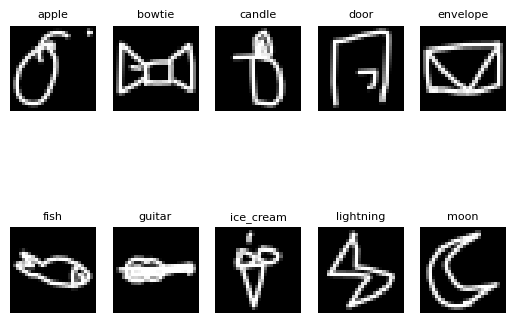

In [2]:
fig, axes = plt.subplots(2, 5)

for ax, name in zip(axes.flat, classes):
    data = np.load(f"data/quickdraw_data/{name}.npy")
    ax.imshow(data[0].reshape(28, 28), cmap="gray")
    ax.set_title(name, fontsize=8)
    ax.axis("off")

plt.show()

In [2]:
paths = glob.glob("data/quickdraw_data/*.npy")
max_per_class = 10_000

data_list = []

for path in paths:
    arr = np.load(path)
    if len(arr) > max_per_class:
        arr = arr[:max_per_class]
    data_list.append(arr)

data = np.concatenate(data_list, axis=0)

labels = []
for idx, data_element in enumerate(data_list):
    class_name = classes[idx]
    n_samples = len(data_element)
    labels.extend([class_name] * n_samples)

encoder = LabelEncoder()
labels = encoder.fit_transform(labels)

ValueError: need at least one array to concatenate

In [3]:
data = data / 255.0

x, x_test, y, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42, stratify=labels
)
x_train, x_val, y_train, y_val = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

path = "D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt"
cp = tf.keras.callbacks.ModelCheckpoint(filepath=path, save_weights_only=True, verbose=1)

In [4]:
def show_loss(hist):
    loss     = hist.history['loss']
    val_loss = hist.history['val_loss']
    epochs   = range(len(loss))
    plt.figure()
    plt.plot  ( epochs,loss )
    plt.plot  ( epochs,val_loss )
    plt.title ('Training and validation loss')

def show_accuracy(hist):
    acc = hist.history['accuracy']
    val_acc  = hist.history['val_accuracy']
    epochs   = range(len(acc))
    plt.figure()
    plt.plot  ( epochs,     acc )
    plt.plot  ( epochs, val_acc )
    plt.title ('Training and validation accuracy')

Epoch 1/10
2000/2000 [==============================] - ETA: 0s - loss: 0.5134 - accuracy: 0.8498
Epoch 1: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 5s 2ms/step - loss: 0.5134 - accuracy: 0.8498 - val_loss: 0.3916 - val_accuracy: 0.8842
Epoch 2/10
1986/2000 [============================>.] - ETA: 0s - loss: 0.3397 - accuracy: 0.9009
Epoch 2: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 4s 2ms/step - loss: 0.3393 - accuracy: 0.9010 - val_loss: 0.3554 - val_accuracy: 0.8976
Epoch 3/10
1982/2000 [============================>.] - ETA: 0s - loss: 0.2814 - accuracy: 0.9176
Epoch 3: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 4s 2ms/step - loss: 0.2819 - accuracy: 0.9175 - val_loss: 0.3366 - val_accuracy: 0.9054
Epoch 4/10
1992/2000 [============================>.] - ETA: 0s - loss: 0.2414 - accuracy: 0.9

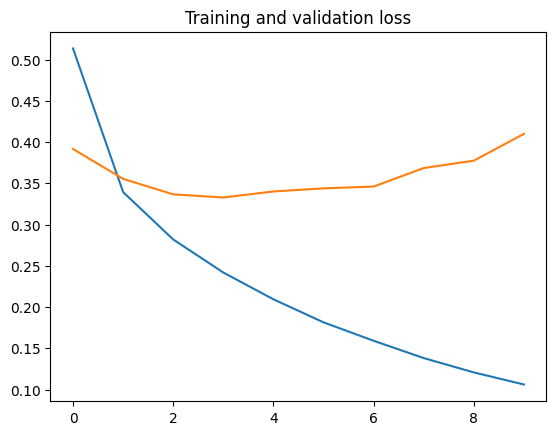

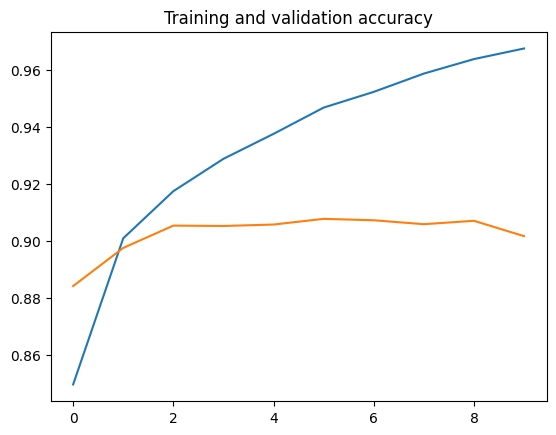

In [20]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(128, activation='relu', input_shape=(784,)),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_val, y_val), callbacks=[cp])

show_loss(history)
show_accuracy(history)

Epoch 1/10
1979/2000 [============================>.] - ETA: 0s - loss: 2.3876 - accuracy: 0.7245
Epoch 1: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 5s 3ms/step - loss: 2.3780 - accuracy: 0.7252 - val_loss: 1.5173 - val_accuracy: 0.7636
Epoch 2/10
1992/2000 [============================>.] - ETA: 0s - loss: 1.4497 - accuracy: 0.7742
Epoch 2: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 5s 2ms/step - loss: 1.4496 - accuracy: 0.7742 - val_loss: 1.4173 - val_accuracy: 0.7799
Epoch 3/10
1980/2000 [============================>.] - ETA: 0s - loss: 1.3800 - accuracy: 0.7828
Epoch 3: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 5s 2ms/step - loss: 1.3796 - accuracy: 0.7831 - val_loss: 1.3460 - val_accuracy: 0.7825
Epoch 4/10
1988/2000 [============================>.] - ETA: 0s - loss: 1.3331 - accuracy: 0.7

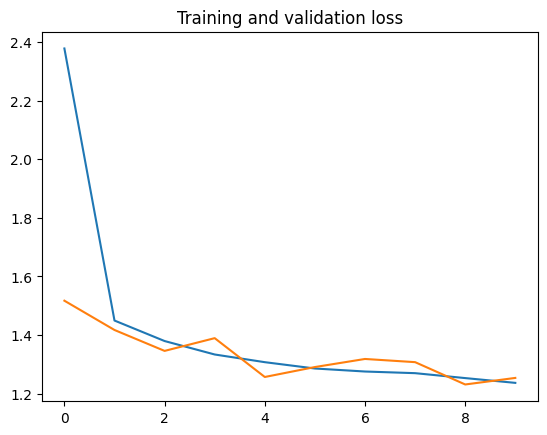

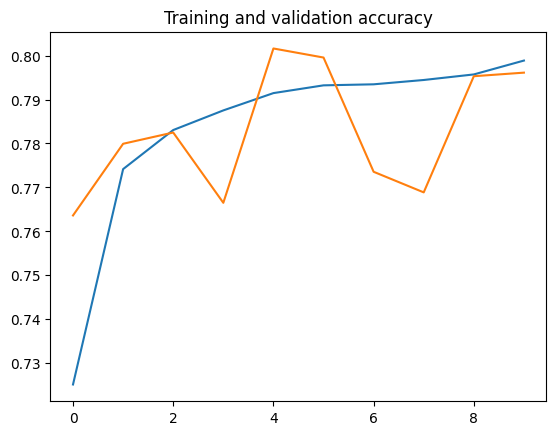

In [36]:
# Додав регуляризацію
model = tf.keras.models.Sequential([
   tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.01)),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_val, y_val), callbacks=[cp])

show_loss(history)
show_accuracy(history)

Epoch 1/10
1976/2000 [============================>.] - ETA: 0s - loss: 0.7723 - accuracy: 0.8432
Epoch 1: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 5s 2ms/step - loss: 0.7703 - accuracy: 0.8437 - val_loss: 0.6376 - val_accuracy: 0.8708
Epoch 2/10
1988/2000 [============================>.] - ETA: 0s - loss: 0.5657 - accuracy: 0.8889
Epoch 2: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 5s 2ms/step - loss: 0.5656 - accuracy: 0.8890 - val_loss: 0.5506 - val_accuracy: 0.8939
Epoch 3/10
1992/2000 [============================>.] - ETA: 0s - loss: 0.5167 - accuracy: 0.9004
Epoch 3: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 5s 2ms/step - loss: 0.5166 - accuracy: 0.9004 - val_loss: 0.5318 - val_accuracy: 0.8973
Epoch 4/10
1980/2000 [============================>.] - ETA: 0s - loss: 0.4888 - accuracy: 0.9

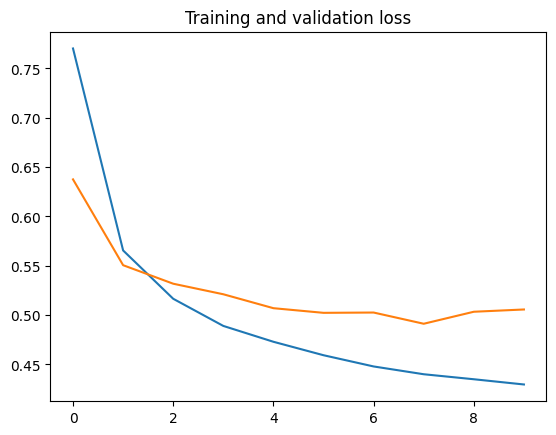

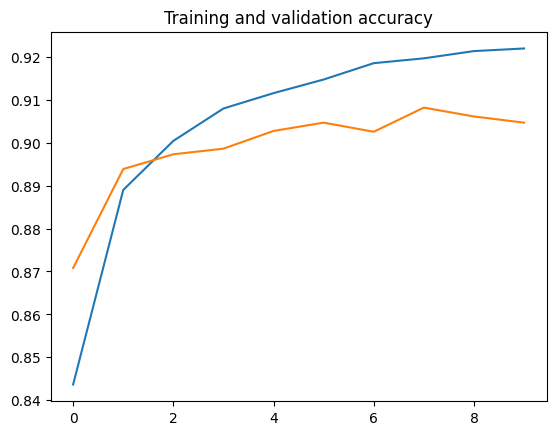

In [37]:
# Зменшив регуляризацію
model = tf.keras.models.Sequential([
   tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l1(0.0001)),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_val, y_val), callbacks=[cp])

show_loss(history)
show_accuracy(history)

Epoch 1/10
2000/2000 [==============================] - ETA: 0s - loss: 1.6719 - accuracy: 0.5805
Epoch 1: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 6s 2ms/step - loss: 1.6719 - accuracy: 0.5805 - val_loss: 1.3624 - val_accuracy: 0.7026
Epoch 2/10
1997/2000 [============================>.] - ETA: 0s - loss: 1.2801 - accuracy: 0.7126
Epoch 2: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 5s 2ms/step - loss: 1.2799 - accuracy: 0.7127 - val_loss: 1.1689 - val_accuracy: 0.7648
Epoch 3/10
1998/2000 [============================>.] - ETA: 0s - loss: 1.1407 - accuracy: 0.7513
Epoch 3: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 5s 2ms/step - loss: 1.1405 - accuracy: 0.7514 - val_loss: 1.0635 - val_accuracy: 0.7811
Epoch 4/10
2000/2000 [==============================] - ETA: 0s - loss: 1.0516 - accuracy: 0.7

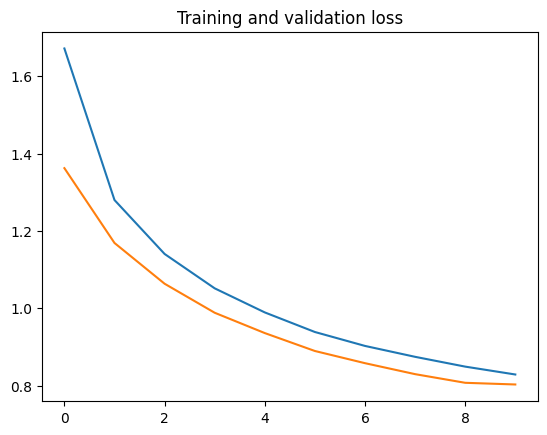

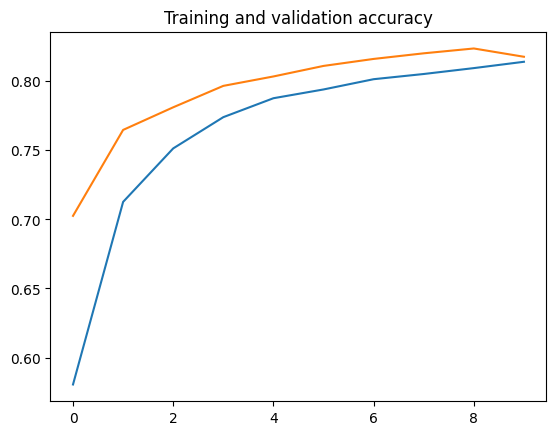

In [8]:
# Змінив регуляризацію на l2 та додав Dropout
model = tf.keras.models.Sequential([
   tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_val, y_val), callbacks=[cp])

show_loss(history)
show_accuracy(history)

Epoch 1/10
1979/2000 [============================>.] - ETA: 0s - loss: 1.1522 - accuracy: 0.6846
Epoch 1: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 5s 2ms/step - loss: 1.1500 - accuracy: 0.6853 - val_loss: 0.9673 - val_accuracy: 0.7551
Epoch 2/10
1986/2000 [============================>.] - ETA: 0s - loss: 0.8964 - accuracy: 0.7835
Epoch 2: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 5s 2ms/step - loss: 0.8962 - accuracy: 0.7835 - val_loss: 0.8652 - val_accuracy: 0.7958
Epoch 3/10
1975/2000 [============================>.] - ETA: 0s - loss: 0.8067 - accuracy: 0.8147
Epoch 3: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 5s 2ms/step - loss: 0.8063 - accuracy: 0.8148 - val_loss: 0.7937 - val_accuracy: 0.8127
Epoch 4/10
1984/2000 [============================>.] - ETA: 0s - loss: 0.7527 - accuracy: 0.8

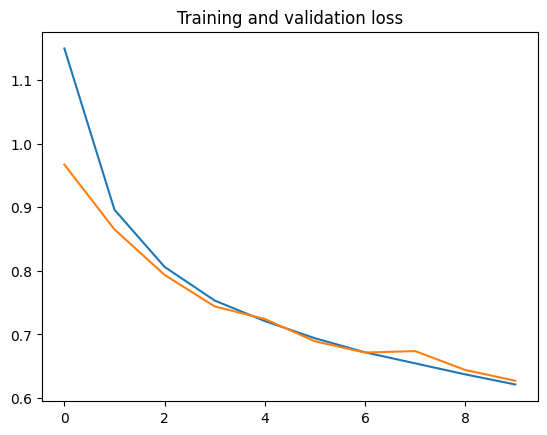

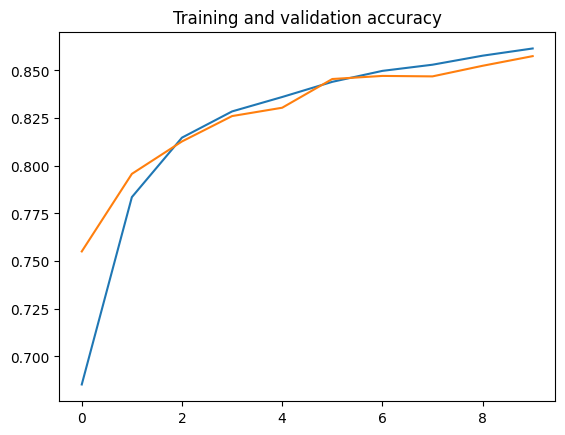

In [9]:
# Прибрав Dropout та додав ще один шар
model = tf.keras.models.Sequential([
   tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_val, y_val), callbacks=[cp])

show_loss(history)
show_accuracy(history)

Epoch 1/20
1983/2000 [============================>.] - ETA: 0s - loss: 1.0901 - accuracy: 0.7123
Epoch 1: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 6s 3ms/step - loss: 1.0882 - accuracy: 0.7129 - val_loss: 0.9022 - val_accuracy: 0.7841
Epoch 2/20
1977/2000 [============================>.] - ETA: 0s - loss: 0.8250 - accuracy: 0.8127
Epoch 2: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 5s 2ms/step - loss: 0.8248 - accuracy: 0.8126 - val_loss: 0.8071 - val_accuracy: 0.8099
Epoch 3/20
1985/2000 [============================>.] - ETA: 0s - loss: 0.7595 - accuracy: 0.8300
Epoch 3: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 5s 2ms/step - loss: 0.7594 - accuracy: 0.8301 - val_loss: 0.7516 - val_accuracy: 0.8273
Epoch 4/20
1979/2000 [============================>.] - ETA: 0s - loss: 0.7157 - accuracy: 0.8

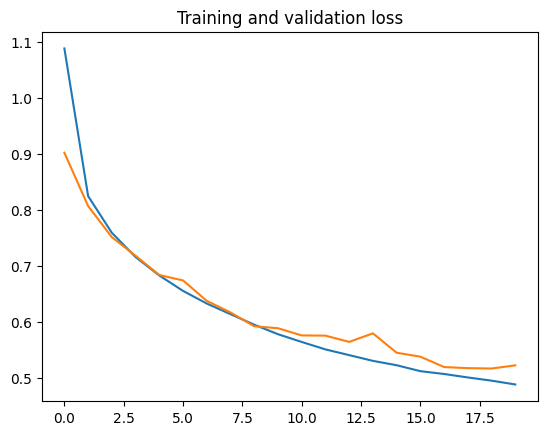

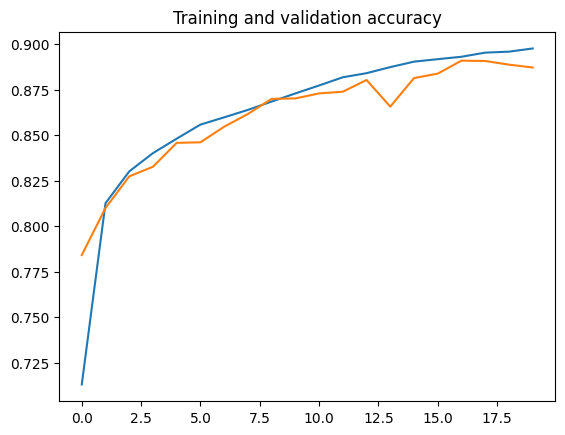

In [14]:
# Збільшив кількість нейронів та кількість епох
model = tf.keras.models.Sequential([
   tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_val, y_val), callbacks=[cp])

show_loss(history)
show_accuracy(history)

Epoch 1/20
1984/2000 [============================>.] - ETA: 0s - loss: 0.5239 - accuracy: 0.8617
Epoch 1: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 8s 3ms/step - loss: 0.5237 - accuracy: 0.8618 - val_loss: 0.4397 - val_accuracy: 0.8924
Epoch 2/20
1992/2000 [============================>.] - ETA: 0s - loss: 0.4023 - accuracy: 0.9018
Epoch 2: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 6s 3ms/step - loss: 0.4022 - accuracy: 0.9018 - val_loss: 0.4197 - val_accuracy: 0.9004
Epoch 3/20
1995/2000 [============================>.] - ETA: 0s - loss: 0.3696 - accuracy: 0.9148
Epoch 3: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 7s 3ms/step - loss: 0.3695 - accuracy: 0.9148 - val_loss: 0.3927 - val_accuracy: 0.9161
Epoch 4/20
1989/2000 [============================>.] - ETA: 0s - loss: 0.3473 - accuracy: 0.9

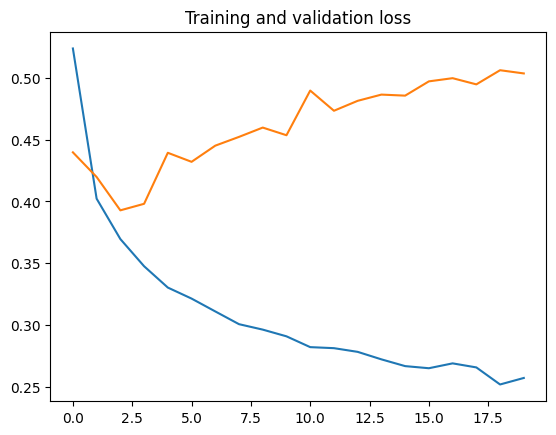

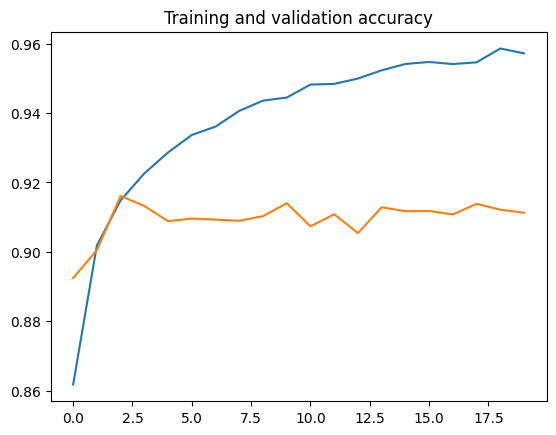

In [6]:
# Додав BatchNormalization
model = tf.keras.models.Sequential([
   tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_val, y_val), callbacks=[cp])

show_loss(history)
show_accuracy(history)

Epoch 1/10
1991/2000 [============================>.] - ETA: 0s - loss: 0.8826 - accuracy: 0.8498
Epoch 1: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 8s 4ms/step - loss: 0.8820 - accuracy: 0.8498 - val_loss: 0.6354 - val_accuracy: 0.8854
Epoch 2/10
1997/2000 [============================>.] - ETA: 0s - loss: 0.6186 - accuracy: 0.8784
Epoch 2: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 7s 3ms/step - loss: 0.6184 - accuracy: 0.8784 - val_loss: 0.5734 - val_accuracy: 0.8886
Epoch 3/10
1990/2000 [============================>.] - ETA: 0s - loss: 0.5725 - accuracy: 0.8838
Epoch 3: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 7s 4ms/step - loss: 0.5722 - accuracy: 0.8839 - val_loss: 0.5425 - val_accuracy: 0.8927
Epoch 4/10
1996/2000 [============================>.] - ETA: 0s - loss: 0.5602 - accuracy: 0.8

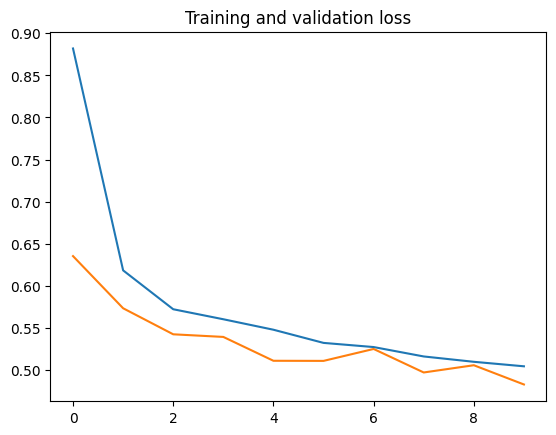

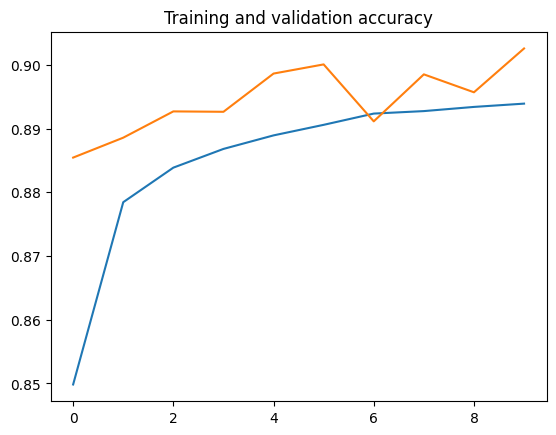

In [8]:
# Збільшив регуляризацію та додав Dropout
model = tf.keras.models.Sequential([
   tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_val, y_val), callbacks=[cp])

show_loss(history)
show_accuracy(history)

In [5]:
es = callbacks.EarlyStopping(monitor='val_loss', mode='min', patience=3, restore_best_weights=True)
rlr = callbacks.ReduceLROnPlateau(monitor='val_loss', mode='min', factor=0.5, patience=1, min_lr=1e-5, verbose=1)

Epoch 1/10
1991/2000 [============================>.] - ETA: 0s - loss: 0.8865 - accuracy: 0.8493
Epoch 1: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 10s 4ms/step - loss: 0.8856 - accuracy: 0.8495 - val_loss: 0.6433 - val_accuracy: 0.8861 - lr: 0.0010
Epoch 2/10
1994/2000 [============================>.] - ETA: 0s - loss: 0.6191 - accuracy: 0.8784
Epoch 2: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 8s 4ms/step - loss: 0.6190 - accuracy: 0.8784 - val_loss: 0.5640 - val_accuracy: 0.8891 - lr: 0.0010
Epoch 3/10
1990/2000 [============================>.] - ETA: 0s - loss: 0.5726 - accuracy: 0.8840
Epoch 3: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 8s 4ms/step - loss: 0.5729 - accuracy: 0.8839 - val_loss: 0.5379 - val_accuracy: 0.8956 - lr: 0.0010
Epoch 4/10
1989/2000 [============================>.] 

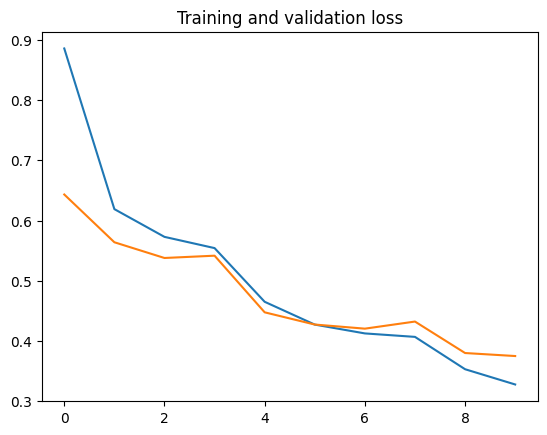

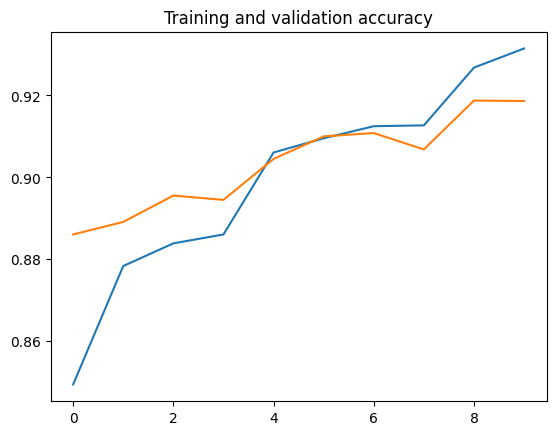

In [7]:
# Додав EarlyStopping та ReduceLROnPlateau
model = tf.keras.models.Sequential([
   tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=10, batch_size=32, validation_data=(x_val, y_val), callbacks=[cp, es, rlr])

show_loss(history)
show_accuracy(history)

Epoch 1/20
1991/2000 [============================>.] - ETA: 0s - loss: 1.2263 - accuracy: 0.7815
Epoch 1: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 11s 5ms/step - loss: 1.2255 - accuracy: 0.7815 - val_loss: 0.9786 - val_accuracy: 0.8024 - lr: 0.0100
Epoch 2/20
1997/2000 [============================>.] - ETA: 0s - loss: 0.9676 - accuracy: 0.7961
Epoch 2: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 10s 5ms/step - loss: 0.9674 - accuracy: 0.7961 - val_loss: 0.8830 - val_accuracy: 0.8184 - lr: 0.0100
Epoch 3/20
1993/2000 [============================>.] - ETA: 0s - loss: 0.9289 - accuracy: 0.7978
Epoch 3: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 11s 5ms/step - loss: 0.9285 - accuracy: 0.7980 - val_loss: 0.8509 - val_accuracy: 0.8126 - lr: 0.0100
Epoch 4/20
1997/2000 [============================>.

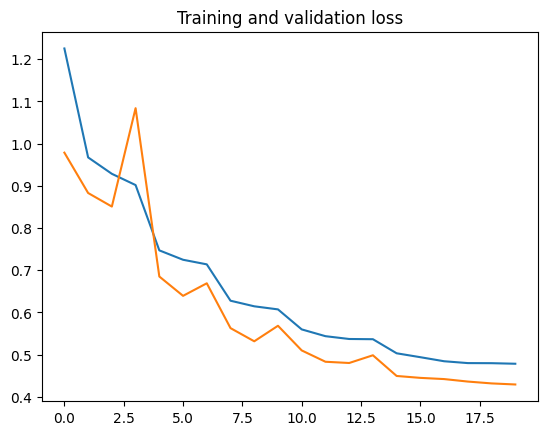

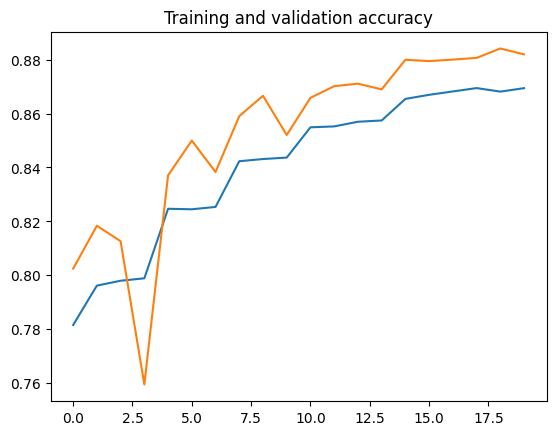

In [6]:
# Збільшив кількість епох та змінив lr
model = tf.keras.models.Sequential([
   tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_val, y_val), callbacks=[cp, es, rlr])

show_loss(history)
show_accuracy(history)

Epoch 1/20
2000/2000 [==============================] - ETA: 0s - loss: 1.3612 - accuracy: 0.7672
Epoch 1: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 10s 5ms/step - loss: 1.3612 - accuracy: 0.7672 - val_loss: 1.1271 - val_accuracy: 0.7846 - lr: 0.0100
Epoch 2/20
1990/2000 [============================>.] - ETA: 0s - loss: 1.1492 - accuracy: 0.7710
Epoch 2: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 10s 5ms/step - loss: 1.1489 - accuracy: 0.7710 - val_loss: 1.0127 - val_accuracy: 0.8082 - lr: 0.0100
Epoch 3/20
1988/2000 [============================>.] - ETA: 0s - loss: 1.0862 - accuracy: 0.7711
Epoch 3: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 9s 5ms/step - loss: 1.0862 - accuracy: 0.7710 - val_loss: 1.0124 - val_accuracy: 0.7889 - lr: 0.0100
Epoch 4/20
1995/2000 [============================>.]

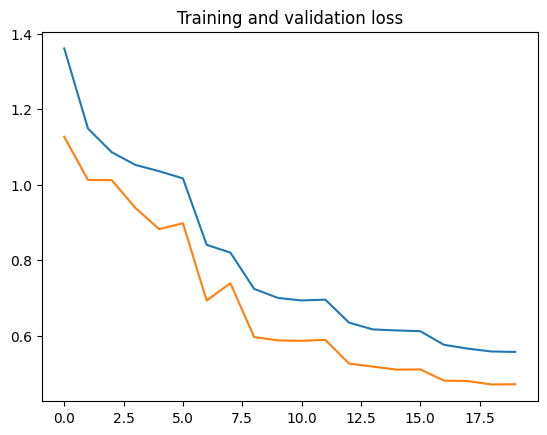

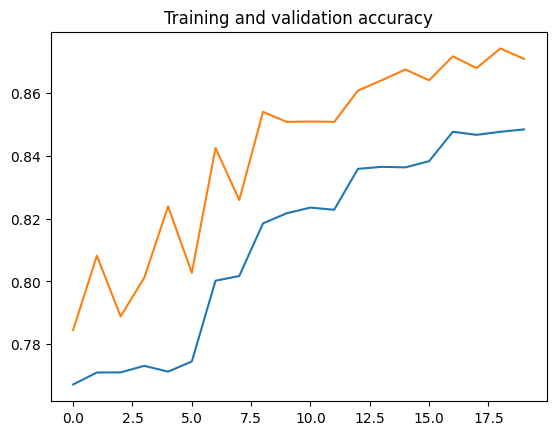

In [7]:
# Збільшив Dropout
model = tf.keras.models.Sequential([
   tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_val, y_val), callbacks=[cp, es, rlr])

show_loss(history)
show_accuracy(history)

Epoch 1/30
1987/2000 [============================>.] - ETA: 0s - loss: 1.2421 - accuracy: 0.7819
Epoch 1: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 10s 5ms/step - loss: 1.2402 - accuracy: 0.7821 - val_loss: 0.9644 - val_accuracy: 0.8154 - lr: 0.0100
Epoch 2/30
1991/2000 [============================>.] - ETA: 0s - loss: 0.9961 - accuracy: 0.7945
Epoch 2: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 9s 5ms/step - loss: 0.9961 - accuracy: 0.7945 - val_loss: 0.9454 - val_accuracy: 0.8044 - lr: 0.0100
Epoch 3/30
1989/2000 [============================>.] - ETA: 0s - loss: 0.9295 - accuracy: 0.7997
Epoch 3: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 9s 5ms/step - loss: 0.9289 - accuracy: 0.7998 - val_loss: 0.8567 - val_accuracy: 0.8201 - lr: 0.0100
Epoch 4/30
1989/2000 [============================>.] 

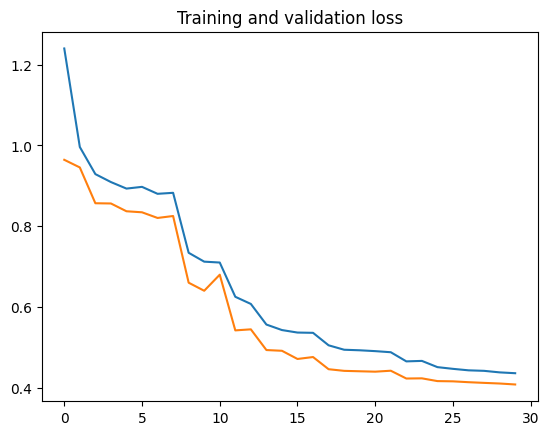

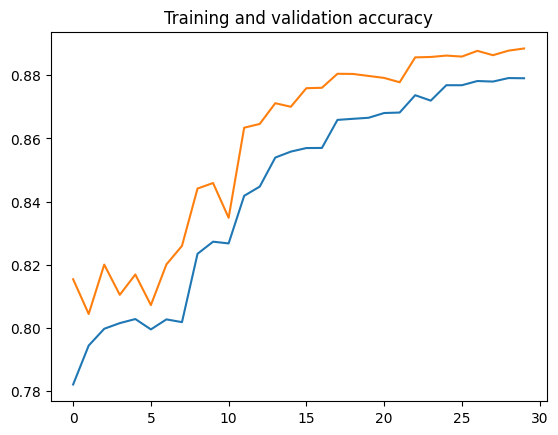

In [8]:

model = tf.keras.models.Sequential([
   tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=30, batch_size=32, validation_data=(x_val, y_val), callbacks=[cp, es, rlr])

show_loss(history)
show_accuracy(history)

Epoch 1/20
1996/2000 [============================>.] - ETA: 0s - loss: 0.8890 - accuracy: 0.7424
Epoch 1: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 12s 6ms/step - loss: 0.8888 - accuracy: 0.7425 - val_loss: 0.5361 - val_accuracy: 0.8591 - lr: 1.0000e-04
Epoch 2/20
2000/2000 [==============================] - ETA: 0s - loss: 0.5989 - accuracy: 0.8375
Epoch 2: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 12s 6ms/step - loss: 0.5989 - accuracy: 0.8375 - val_loss: 0.4694 - val_accuracy: 0.8777 - lr: 1.0000e-04
Epoch 3/20
1998/2000 [============================>.] - ETA: 0s - loss: 0.5329 - accuracy: 0.8596
Epoch 3: saving model to D:\PycharmProjects\DeepLearningU\Lab1\cp.ckpt
2000/2000 [==============================] - 11s 6ms/step - loss: 0.5329 - accuracy: 0.8595 - val_loss: 0.4338 - val_accuracy: 0.8889 - lr: 1.0000e-04
Epoch 4/20
1996/2000 [==================

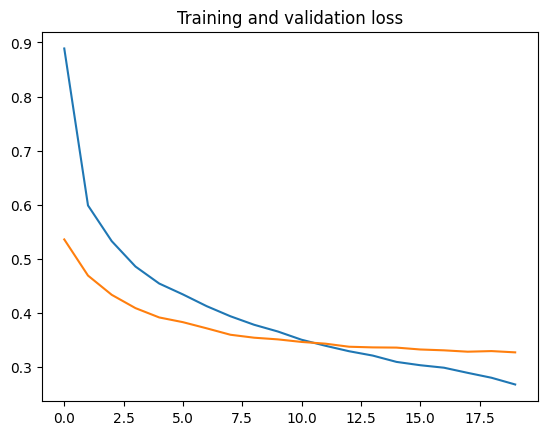

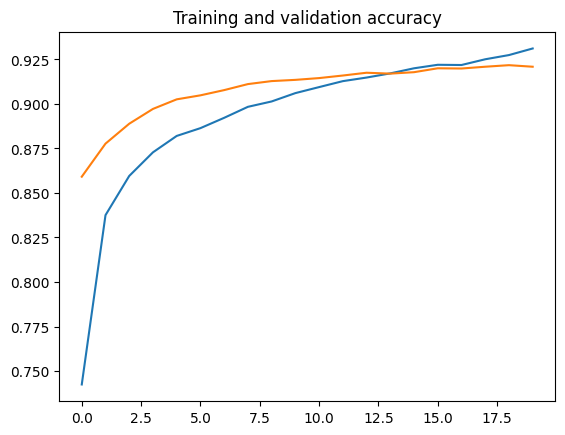

In [12]:
# Змінив архітектуру моделі
model = tf.keras.models.Sequential([
   tf.keras.layers.Dense(256, use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(256, use_bias=False, kernel_regularizer=tf.keras.regularizers.l2(0.0001)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.ReLU(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(10, activation='softmax')
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(x_train, y_train, epochs=20, batch_size=32, validation_data=(x_val, y_val), callbacks=[cp, es, rlr])

show_loss(history)
show_accuracy(history)

In [14]:
model.save('best_model.keras')

In [ ]:
# input_layer = tf.keras.Input(shape=(28, 28))
# layer1 = tf.keras.layers.Flatten()(input_layer)
# layer2 = tf.keras.layers.Dense(256, activation='relu')(layer1)
# layer3 = tf.keras.layers.Dense(128, activation='relu')(layer1)
# merge = tf.keras.layers.Concatenate()([layer2, layer3])
# output = tf.keras.layers.Dense(10, activation='softmax')(merge)
# func_model = tf.keras.Model(inputs=input_layer, outputs=output)

In [19]:
latest = tf.train.latest_checkpoint('Lab1')
model.load_weights(latest)

625/625 - 1s - loss: 0.3334 - accuracy: 0.9287 - 1s/epoch - 2ms/step


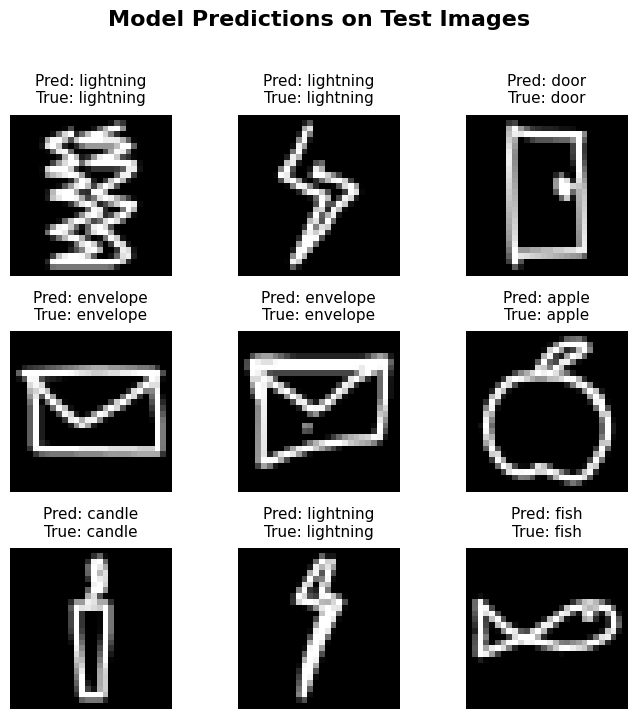

In [11]:
best_model = tf.keras.models.load_model('best_model.keras')
indices = np.random.choice(len(x_test), 9, replace=False)

best_model.evaluate(x_test, y_test, verbose=2)

plt.figure(figsize=(7, 7))
for i, idx in enumerate(indices):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[idx].reshape(28, 28), cmap='gray')

    prediction = best_model.predict(x_test[idx:idx+1], verbose=0)
    pred_class = np.argmax(prediction)
    true_class = y_test[idx]


    plt.title(
        f"Pred: {classes[pred_class]}\nTrue: {classes[true_class]}",
        fontsize=11,
        pad=8
    )
    plt.axis("off")

plt.suptitle("Model Predictions on Test Images", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()